# Human Pose Estimation Using a Pre-Trained Deep Learning Model

## Individual Mini Project

**Student:** Jahnavi Pilla  
**Branch:** Computer Science and Engineering  
**College:** GMR Institute of Technology  

### Project Objective
Detect human body keypoints from images and video using a pre-trained pose estimation model, perform inference and post-processing, and demonstrate a practical computer-vision application.

> **Important:** This project uses a pre-trained model. No deep-learning model is trained from scratch.


## 1. Problem Statement

Human pose estimation identifies important points on the human body from images or video. Manual identification of body joints is difficult and time-consuming. This project uses a pre-trained pose estimation model to automatically detect human body landmarks and visualize the human skeleton.

### Users / Applications
- Fitness and exercise applications
- Sports movement analysis
- Posture monitoring
- Rehabilitation systems
- Human-computer interaction

### Expected Output
For an input image/video frame, the system produces detected human body landmarks and a connected skeleton.


## 2. Objectives

1. Understand pre-trained deep-learning models.
2. Load and use a pre-trained pose estimation model.
3. Understand model input and output.
4. Perform inference on new images.
5. Extract 33 human pose landmarks.
6. Convert normalized coordinates to pixel coordinates.
7. Visualize keypoints and skeleton connections.
8. Process video frames.
9. Measure a simple pose-detection rate.
10. Discuss limitations and future improvements.


## 3. Pre-Trained Model Information

### Model
**MediaPipe Pose Landmarker**

### Model Type
Pre-trained human pose landmark detection model.

### Input
An RGB image. The task API also supports video and live-stream modes.

### Output
A `PoseLandmarkerResult` containing detected pose landmarks. Each pose has **33 landmarks**. The result can also include world-coordinate landmarks and, depending on configuration/model support, segmentation masks.

### Why suitable?
The model is designed specifically for human pose landmark detection and can be used directly for inference without training a new neural network.


## 4. Working Principle

```text
Input Image / Video
        ↓
Pre-processing
        ↓
Pre-trained Pose Landmarker
        ↓
Inference
        ↓
33 Human Body Landmarks
        ↓
Post-processing
        ↓
Pixel-coordinate conversion
        ↓
Skeleton visualization
        ↓
Final Output
```

### Training vs Inference
- **Training:** model weights are learned/updated using training data.
- **Inference:** learned weights are kept fixed and the model predicts outputs for new inputs.
- **This project:** inference only.


## 5. Model Source and License

**Framework/model:** MediaPipe Pose Landmarker  
**Developer:** Google / Google AI Edge  
**Repository:** https://github.com/google-ai-edge/mediapipe  
**Documentation:** https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python  
**Repository license:** Apache License 2.0

The model bundle is downloaded from Google's MediaPipe model storage by the notebook if it is not already present.


## 6. Libraries and Requirements

- Python 3.9+
- MediaPipe
- OpenCV
- NumPy
- Matplotlib
- Requests

The notebook is designed for Jupyter Notebook / JupyterLab / Google Colab.


In [1]:
# Install required packages
%pip install -q mediapipe opencv-python numpy matplotlib requests


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import requests

print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)

MediaPipe: 1.0.1
OpenCV: 5.0.0


In [2]:
import os
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
import mediapipe as mp

from IPython.display import display, Video

print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)


MediaPipe: 1.0.1
OpenCV: 5.0.0


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

from pathlib import Path
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

BaseOptions = python.BaseOptions
PoseLandmarker = vision.PoseLandmarker
PoseLandmarkerOptions = vision.PoseLandmarkerOptions
VisionRunningMode = vision.RunningMode

## 7. Project Folders

The notebook expects this structure:

```text
Human_Pose_Estimation_Pretrained_Project/
├── Human_Pose_Estimation.ipynb
├── requirements.txt
├── README.md
├── images/
├── videos/
├── models/
└── outputs/
```

Place your own test images in `images/` and a test video in `videos/`.


In [3]:
from pathlib import Path
BASE_DIR = Path.cwd()
IMAGE_DIR = BASE_DIR / "images"
VIDEO_DIR = BASE_DIR / "videos"
MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

for folder in [IMAGE_DIR, VIDEO_DIR, MODEL_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE_DIR)
print("Folders created successfully!")


Project directory: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project
Folders created successfully!


In [4]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"

MODEL_PATH = MODEL_DIR / "pose_landmarker_full.task"

def download_model():
    if MODEL_PATH.exists() and MODEL_PATH.stat().st_size > 1_000_000:
        print("Model already exists!")
        print("Location:", MODEL_PATH)
        return

    print("Downloading pre-trained Pose Landmarker model...")

    response = requests.get(
        MODEL_URL,
        stream=True,
        timeout=60
    )

    response.raise_for_status()

    with open(MODEL_PATH, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("Model downloaded successfully!")
    print("Location:", MODEL_PATH)
    print(
        "Model size:",
        round(MODEL_PATH.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

download_model()

Model already exists!
Location: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project\models\pose_landmarker_full.task


In [8]:
import mediapipe as mp

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("MediaPipe Pose Landmarker components loaded successfully!")

MediaPipe Pose Landmarker components loaded successfully!


In [7]:
options = PoseLandmarkerOptions(
    base_options=BaseOptions(
        model_asset_path=str(MODEL_PATH)
    ),
    running_mode=VisionRunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

print("Model options created successfully!")

Model options created successfully!


In [10]:
landmarker = PoseLandmarker.create_from_options(options)

print("Pre-trained Pose Landmarker loaded successfully!")

Pre-trained Pose Landmarker loaded successfully!


## 8. Download the Pre-Trained Model

The notebook uses Google's **Pose Landmarker Full** model bundle.

If the model file is missing, the following cell downloads it automatically. Internet access is required for the first download.

**Model file:** `pose_landmarker_full.task`


In [8]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
MODEL_PATH = MODEL_DIR / "pose_landmarker_full.task"

def download_model():
    if MODEL_PATH.exists() and MODEL_PATH.stat().st_size > 1_000_000:
        print("Model already exists:", MODEL_PATH)
        return

    print("Downloading pre-trained Pose Landmarker model...")
    response = requests.get(MODEL_URL, stream=True, timeout=60)
    response.raise_for_status()

    with open(MODEL_PATH, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    print("Model downloaded:", MODEL_PATH)
    print("Size (MB):", round(MODEL_PATH.stat().st_size / (1024**2), 2))

download_model()


Model already exists: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project\models\pose_landmarker_full.task


## 9. Create the Pre-Trained Model

The model is loaded with MediaPipe Tasks. `running_mode=IMAGE` is used for individual images.


In [9]:
BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions

def create_image_landmarker():
    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(MODEL_PATH)),
        running_mode=VisionRunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_segmentation_masks=False
    )
    return PoseLandmarker.create_from_options(options)

print("Model configuration ready.")


Model configuration ready.


## 10. Input Preparation

OpenCV reads images in BGR order. MediaPipe expects RGB image data, so the image is converted before inference.


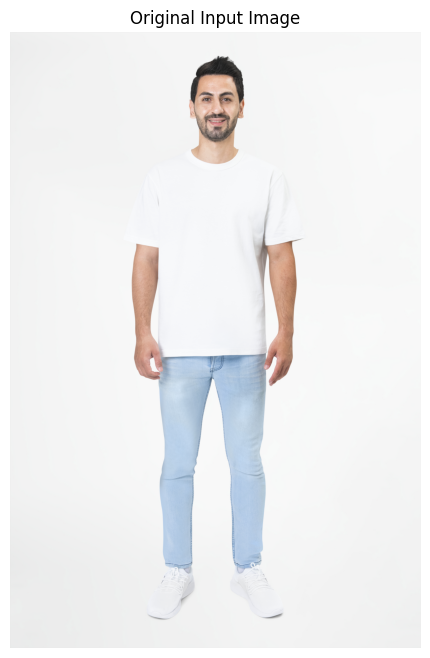

Image shape: (5000, 3333, 3)


In [10]:
# Change this filename to your own image
IMAGE_PATH = IMAGE_DIR / "person1.jpg"

if not IMAGE_PATH.exists():
    print("Please place an image at:", IMAGE_PATH)
else:
    image_bgr = cv2.imread(str(IMAGE_PATH))
    if image_bgr is None:
        raise ValueError("OpenCV could not read the image.")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.title("Original Input Image")
    plt.axis("off")
    plt.show()

    print("Image shape:", image_bgr.shape)


## 11. Model Inference

This is the core inference stage. The pre-trained weights are used to predict body landmarks for a new image.


In [11]:
def run_pose_inference(image_bgr):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    with create_image_landmarker() as landmarker:
        result = landmarker.detect(mp_image)

    return result

if IMAGE_PATH.exists():
    result = run_pose_inference(image_bgr)
    print("Inference completed.")
    print("Number of detected poses:", len(result.pose_landmarks))


Inference completed.
Number of detected poses: 1


## 12. Model Output

The model output contains 33 landmarks for each detected pose.

Each landmark provides normalized image coordinates (`x`, `y`) and a depth-related `z` value. Visibility/presence values can also be available depending on the API/model output.


In [12]:
LANDMARK_NAMES = [
    "Nose", "Left Eye Inner", "Left Eye", "Left Eye Outer",
    "Right Eye Inner", "Right Eye", "Right Eye Outer",
    "Left Ear", "Right Ear", "Mouth Left", "Mouth Right",
    "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
    "Left Wrist", "Right Wrist", "Left Pinky", "Right Pinky",
    "Left Index", "Right Index", "Left Thumb", "Right Thumb",
    "Left Hip", "Right Hip", "Left Knee", "Right Knee",
    "Left Ankle", "Right Ankle", "Left Heel", "Right Heel",
    "Left Foot Index", "Right Foot Index"
]

if IMAGE_PATH.exists() and result.pose_landmarks:
    landmarks = result.pose_landmarks[0]
    print("Number of landmarks:", len(landmarks))

    for i, landmark in enumerate(landmarks):
        print(
            f"{i:2d}  {LANDMARK_NAMES[i]:20s} "
            f"x={landmark.x:.4f}, y={landmark.y:.4f}, z={landmark.z:.4f}"
        )


Number of landmarks: 33
 0  Nose                 x=0.5078, y=0.1266, z=-0.6950
 1  Left Eye Inner       x=0.5261, y=0.1095, z=-0.6496
 2  Left Eye             x=0.5354, y=0.1098, z=-0.6498
 3  Left Eye Outer       x=0.5460, y=0.1103, z=-0.6497
 4  Right Eye Inner      x=0.4925, y=0.1097, z=-0.6548
 5  Right Eye            x=0.4808, y=0.1100, z=-0.6548
 6  Right Eye Outer      x=0.4712, y=0.1105, z=-0.6549
 7  Left Ear             x=0.5604, y=0.1184, z=-0.3603
 8  Right Ear            x=0.4546, y=0.1199, z=-0.3875
 9  Mouth Left           x=0.5275, y=0.1467, z=-0.5847
10  Mouth Right          x=0.4871, y=0.1473, z=-0.5925
11  Left Shoulder        x=0.6403, y=0.2401, z=-0.1765
12  Right Shoulder       x=0.3680, y=0.2317, z=-0.2081
13  Left Elbow           x=0.6664, y=0.3708, z=-0.0660
14  Right Elbow          x=0.3240, y=0.3680, z=-0.1266
15  Left Wrist           x=0.6779, y=0.4905, z=-0.3686
16  Right Wrist          x=0.3242, y=0.4940, z=-0.3785
17  Left Pinky           x=0.6812, y=0.53

## 13. Post-Processing: Convert Normalized Coordinates to Pixels

Normalized coordinates are converted to actual image pixels so that keypoints can be drawn using OpenCV.


In [13]:
def normalized_to_pixels(landmarks, width, height):
    points = []
    for landmark in landmarks:
        x = int(np.clip(landmark.x * width, 0, width - 1))
        y = int(np.clip(landmark.y * height, 0, height - 1))
        points.append((x, y))
    return points

if IMAGE_PATH.exists() and result.pose_landmarks:
    h, w = image_bgr.shape[:2]
    pixel_points = normalized_to_pixels(result.pose_landmarks[0], w, h)

    print("Example pixel coordinates:")
    for i in [0, 11, 12, 23, 24, 27, 28]:
        print(LANDMARK_NAMES[i], ":", pixel_points[i])


Example pixel coordinates:
Nose : (1692, 632)
Left Shoulder : (2133, 1200)
Right Shoulder : (1226, 1158)
Left Hip : (1904, 2539)
Right Hip : (1421, 2533)
Left Ankle : (1949, 4390)
Right Ankle : (1362, 4388)


## 14. Skeleton Connections

The following connections represent major human body chains. They are used only for visualization/post-processing; the pre-trained model itself produces the landmarks.


In [14]:
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27),
    (24, 26), (26, 28),
    (27, 29), (29, 31),
    (28, 30), (30, 32),
    (15, 17), (15, 19), (15, 21),
    (16, 18), (16, 20), (16, 22)
]


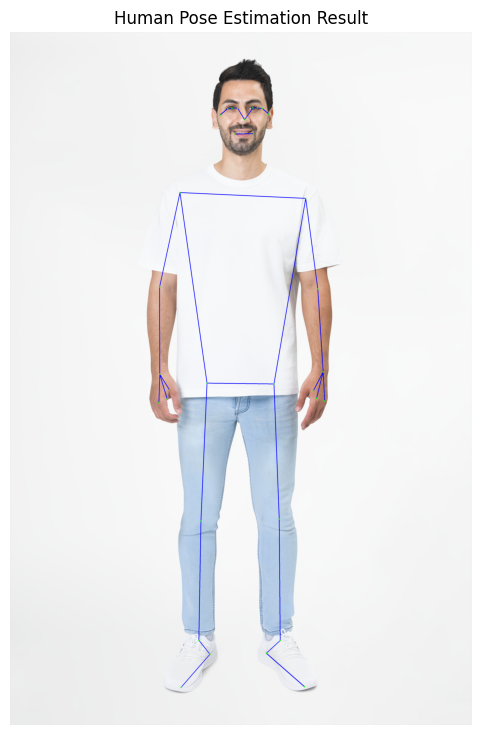

Saved: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project\outputs\pose_result.jpg


In [15]:
def draw_pose(image_bgr, result):
    output = image_bgr.copy()

    if not result.pose_landmarks:
        return output

    h, w = output.shape[:2]
    points = normalized_to_pixels(result.pose_landmarks[0], w, h)

    # Draw connections
    for start, end in POSE_CONNECTIONS:
        cv2.line(
            output,
            points[start],
            points[end],
            (255, 0, 0),
            3
        )

    # Draw landmarks
    for x, y in points:
        cv2.circle(output, (x, y), 5, (0, 255, 0), -1)

    return output

if IMAGE_PATH.exists():
    pose_output = draw_pose(image_bgr, result)

    plt.figure(figsize=(9, 9))
    plt.imshow(cv2.cvtColor(pose_output, cv2.COLOR_BGR2RGB))
    plt.title("Human Pose Estimation Result")
    plt.axis("off")
    plt.show()

    output_image_path = OUTPUT_DIR / "pose_result.jpg"
    cv2.imwrite(str(output_image_path), pose_output)
    print("Saved:", output_image_path)


## 15. Test Case 1

**Input:** Full-body image with one visible person.

**Expected:** The model detects the body landmarks and the output shows a connected skeleton.

**Observation:** Record your observation after running the cell.


In [16]:
# Test Case 1 result summary
if IMAGE_PATH.exists():
    detected = len(result.pose_landmarks) > 0
    print("Test Case 1 - Pose detected:", detected)
    if detected:
        print("Landmarks detected:", len(result.pose_landmarks[0]))


Test Case 1 - Pose detected: True
Landmarks detected: 33


## 16. Test Case 2

Use a second image, preferably with a different pose, viewpoint, or arm position.


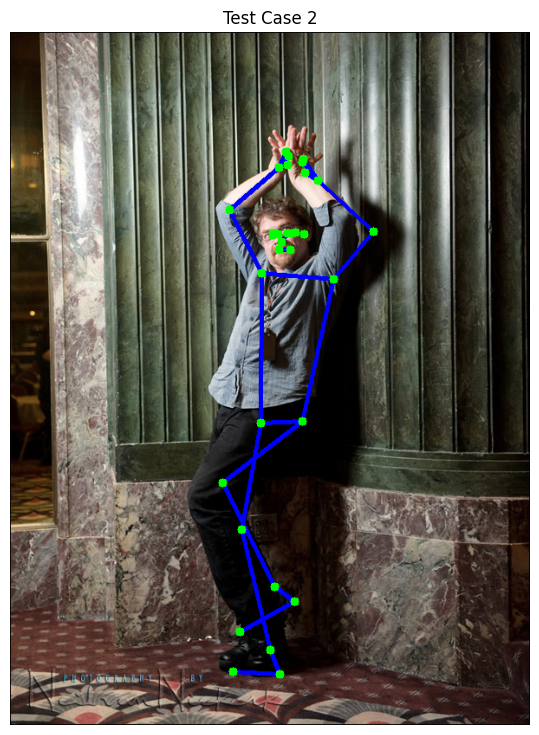

Pose detected: True


In [17]:
IMAGE_PATH_2 = IMAGE_DIR / "person2.jpg"

if IMAGE_PATH_2.exists():
    image2 = cv2.imread(str(IMAGE_PATH_2))
    result2 = run_pose_inference(image2)
    output2 = draw_pose(image2, result2)

    plt.figure(figsize=(9, 9))
    plt.imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))
    plt.title("Test Case 2")
    plt.axis("off")
    plt.show()

    print("Pose detected:", len(result2.pose_landmarks) > 0)
else:
    print("Add a second image:", IMAGE_PATH_2)


## 17. Video Pose Estimation

A video is a sequence of frames. For video inference, the task API uses `VIDEO` running mode and timestamps.

Workflow:

```text
Video → Frame → RGB conversion → Pose inference → Keypoints → Skeleton → Output video
```


In [18]:
VIDEO_PATH = VIDEO_DIR / "pose_video.mp4"
VIDEO_OUTPUT = OUTPUT_DIR / "pose_output.mp4"

if not VIDEO_PATH.exists():
    print("Add a video at:", VIDEO_PATH)
else:
    print("Video found:", VIDEO_PATH)


Video found: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project\videos\pose_video.mp4


In [19]:
def process_video(input_path, output_path):
    cap = cv2.VideoCapture(str(input_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {input_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        fps,
        (width, height)
    )

    video_options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(MODEL_PATH)),
        running_mode=VisionRunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_segmentation_masks=False
    )

    frame_count = 0
    detected_frames = 0

    with PoseLandmarker.create_from_options(video_options) as landmarker:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            timestamp_ms = int((frame_count / fps) * 1000)

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_frame = mp.Image(
                image_format=mp.ImageFormat.SRGB,
                data=rgb
            )

            result = landmarker.detect_for_video(
                mp_frame,
                timestamp_ms
            )

            if result.pose_landmarks:
                detected_frames += 1

            processed = draw_pose(frame, result)
            writer.write(processed)

            frame_count += 1

    cap.release()
    writer.release()

    detection_rate = (
        detected_frames / frame_count * 100
        if frame_count else 0
    )

    return frame_count, detected_frames, detection_rate

if VIDEO_PATH.exists():
    frames, detected, rate = process_video(
        VIDEO_PATH,
        VIDEO_OUTPUT
    )

    print("Frames processed:", frames)
    print("Frames with pose detected:", detected)
    print(f"Pose detection rate: {rate:.2f}%")
    print("Output video:", VIDEO_OUTPUT)


Frames processed: 302
Frames with pose detected: 268
Pose detection rate: 88.74%
Output video: C:\Users\Janu\Downloads\Human_Pose_Estimation_Pretrained_Project\Human_Pose_Estimation_Pretrained_Project\outputs\pose_output.mp4


## 18. Results / Observations

### Image Results
- The model detects human pose landmarks from an input image.
- 33 landmarks are available for each detected pose.
- Normalized coordinates are converted to pixel coordinates.
- The landmarks are connected to visualize the skeleton.

### Video Results
- The video is processed frame by frame.
- Pose landmarks are detected on video frames.
- The processed frames are saved as an output video.
- A simple detection rate is calculated as:

`detection rate = detected pose frames / total frames × 100`

### Important
This is an inference project, so training loss/accuracy graphs are not required.


## 19. Limitations

1. Occlusion can reduce landmark accuracy.
2. Very small or partially visible people can be difficult to detect.
3. Poor lighting and image quality can affect results.
4. Extreme or unusual poses may produce inaccurate landmarks.
5. The current notebook is primarily designed for one main pose per frame.
6. The system does not by itself classify activities such as yoga poses or exercises.


## 20. Future Scope

1. Real-time webcam pose estimation.
2. Yoga pose classification.
3. Exercise repetition counting.
4. Squat/push-up detection.
5. Posture monitoring.
6. Fall detection.
7. Sports movement analysis.
8. Multi-person pose analysis.
9. Web application deployment.
10. Mobile application integration.


## 21. Conclusion

This project demonstrated the complete workflow of a pre-trained deep learning model:

**Input → Pre-processing → Pre-trained Model → Inference → Post-processing → Output → Practical Application**

The MediaPipe Pose Landmarker was used without training a new deep learning model. The system detects human body landmarks from images and video and visualizes them as a connected skeleton.

The project demonstrates how pre-trained models can reduce development effort while still providing useful real-world computer-vision functionality.


## 22. References

1. Google AI Edge — MediaPipe Pose Landmarker documentation:
   https://ai.google.dev/edge/mediapipe/solutions/vision/pose_landmarker/python

2. MediaPipe Python API:
   https://ai.google.dev/edge/api/mediapipe/python/mp/tasks/vision/PoseLandmarker

3. MediaPipe GitHub repository:
   https://github.com/google-ai-edge/mediapipe

4. MediaPipe Pose Landmarker result/API documentation:
   https://ai.google.dev/edge/api/mediapipe/python/mp/tasks/vision/PoseLandmarkerResult

### Submission Note
Add screenshots of:
- Original input image
- Detected skeleton output
- Keypoint coordinate output
- Test Case 2
- Processed video/output
- Detection-rate result

These screenshots make the notebook clearly demonstrate the assignment's required practical results.
